In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings 
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
sns.set_palette('Pastel2')

In [2]:
with open('data/articles.jsonl', 'r', encoding = 'utf-8') as f:
    data = []
    for line in f:
        obj = json.loads(line)
        data.append(obj)

df = pd.DataFrame(data)
df.head()

,id,title,authors,year,content,url
0,10200301,Accelerated longitudinal changes and ordering ...,"[Jingqin Luo, Folasade Agboola, Elizabeth Gran...",2022,[ABSTRACT] The temporal evolutions and relativ...,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...
1,11281823,Oxidative damage in neurodegeneration: roles i...,"[Marzia Perluigi, Fabio Di Domenico, D. Allan ...",2024,[ABSTRACT] Alzheimer disease (AD) is associate...,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...
2,9989348,Autosomal dominant and sporadic late onset Alz...,"[John C Morris, Michael Weiner, Chengjie Xiong...",2022,[ABSTRACT] The extent to which the pathophysio...,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9...
3,11086901,Brain high-throughput multi-omics data reveal ...,"[Abdallah M. Eteleeb, Brenna C. Novotny, Carol...",2024,[INTRODUCTION] Alzheimer disease (AD) is a het...,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...
4,9337804,Sex differences in the genetic architecture of...,"[Jaclyn M Eissman, Logan Dumitrescu, Emily R M...",2022,[INTRODUCTION] Alzheimer’s disease is a progre...,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9...


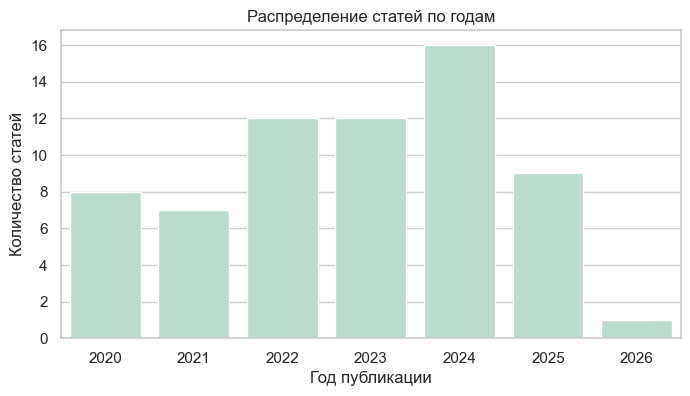

In [3]:
# ==== Проанализируем годы публикации выбранных статей ====
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Распределение статей по годам')
plt.xlabel('Год публикации')
plt.ylabel('Количество статей')
plt.show()

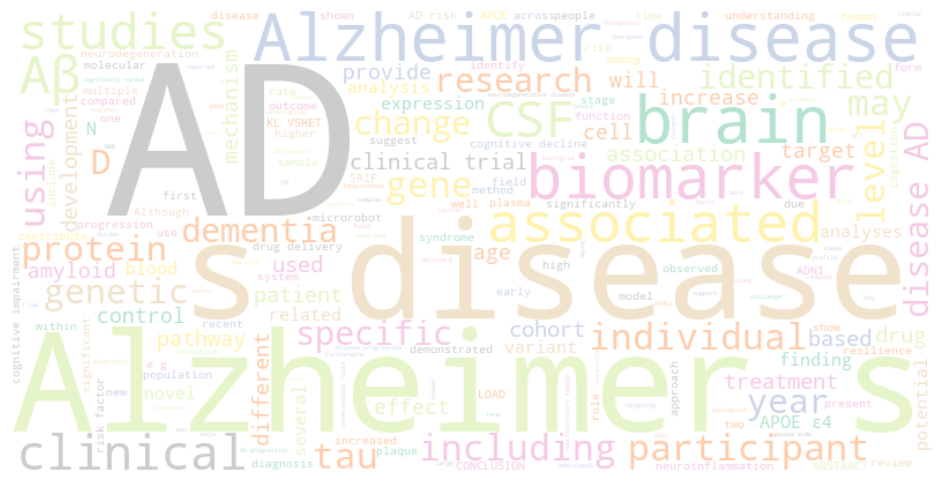

In [4]:
# ==== Визуализируем наиболее часто встречающиеся слова в выбранных фрагментах статей ====
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text = ' '.join(df['content'].astype(str))

stopwords = set(STOPWORDS)
my_stopwords = {'et', 'al', 'study', 'figure', 'table', 'data', 'results'}
stopwords.update(my_stopwords)

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    stopwords=stopwords, 
    colormap='Pastel2'  
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

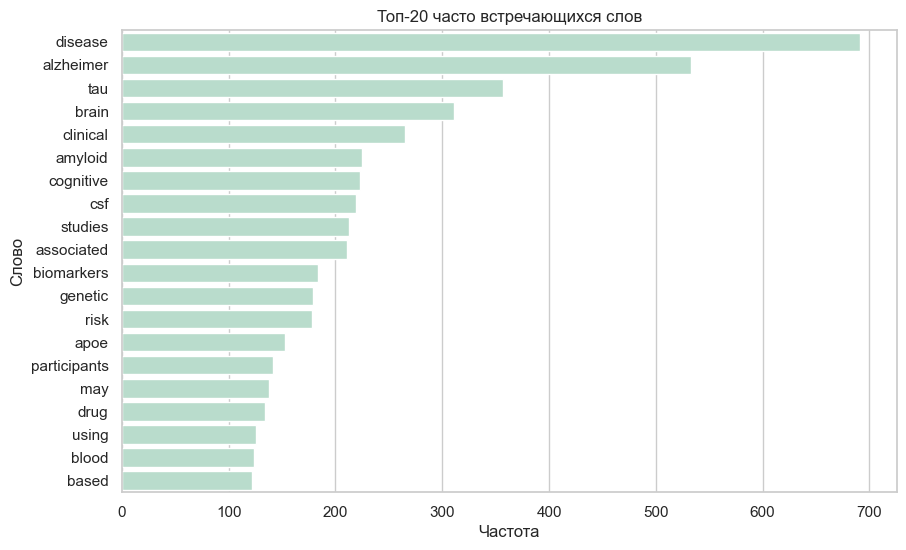

In [5]:
from collections import Counter
import re

words = re.findall(r'\b\w+\b', text.lower())
filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

word_counts = Counter(filtered_words)
common_words = word_counts.most_common(20)

words, counts = zip(*common_words)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Топ-20 часто встречающихся слов')
plt.xlabel('Частота')
plt.ylabel('Слово')
plt.show()

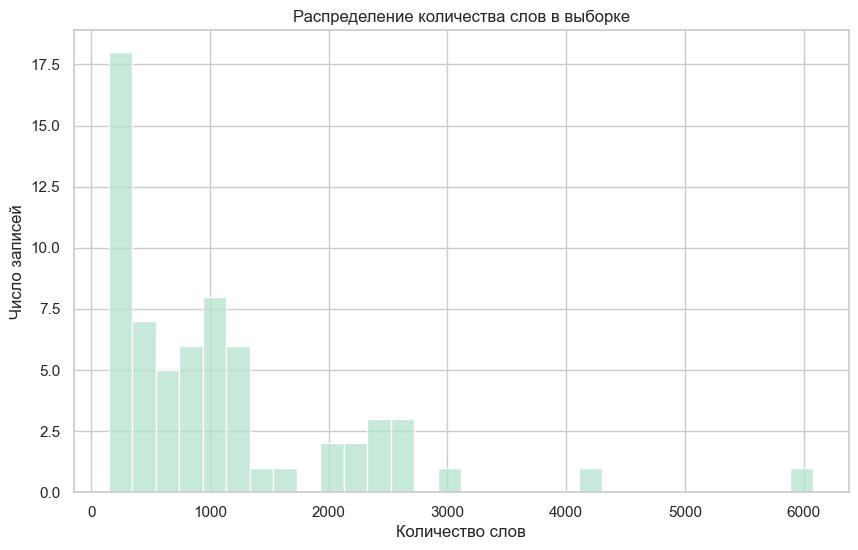

In [6]:
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=30)
plt.title('Распределение количества слов в выборке')
plt.xlabel('Количество слов')
plt.ylabel('Число записей')
plt.show()